In [1]:
print("hello world")

hello world


1 faces detected!
<class 'numpy.ndarray'>


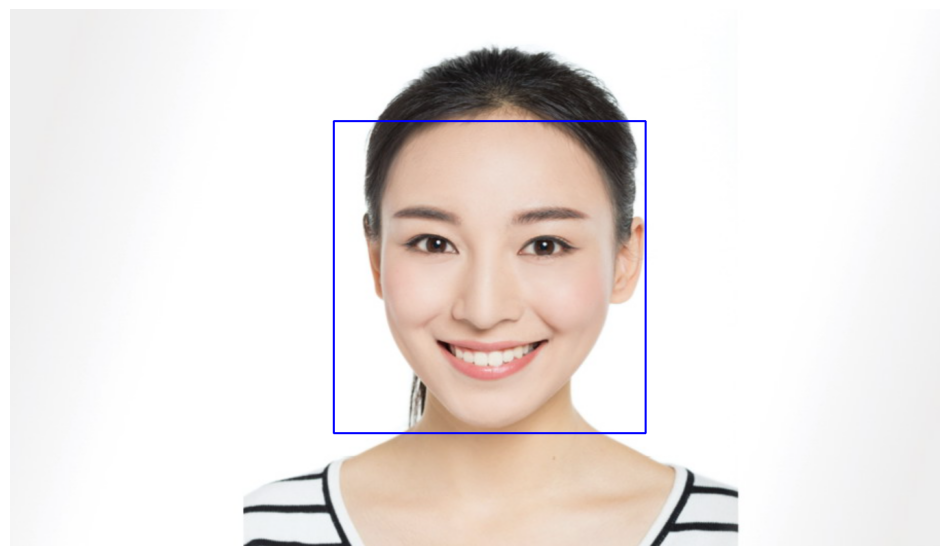

In [14]:
import cv2
import matplotlib.pyplot as plt # 用于绘制图像
# 加载级联
face_cascade = cv2.CascadeClassifier('D:/Program Files/Python310/Lib/site-packages/cv2/data/haarcascade_frontalface_default.xml')
# 读取输入图像
img = cv2.imread('test.png')
cv2.imshow('img',img)
# 检测人脸
faces = face_cascade.detectMultiScale(image=img, scaleFactor=1.1, minNeighbors=5)
# 在人脸周围绘制边界框
for (x, y, w, h) in faces:
  cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
 # 显示图像中检测到的人脸数量
print(len(faces),"faces detected!")
# 绘制检测到人脸的图像
print(type(img))
finalimg =cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,12))
plt.imshow(finalimg)
plt.axis("off")
plt.show()

(783, 1357, 3)
<class 'numpy.ndarray'>


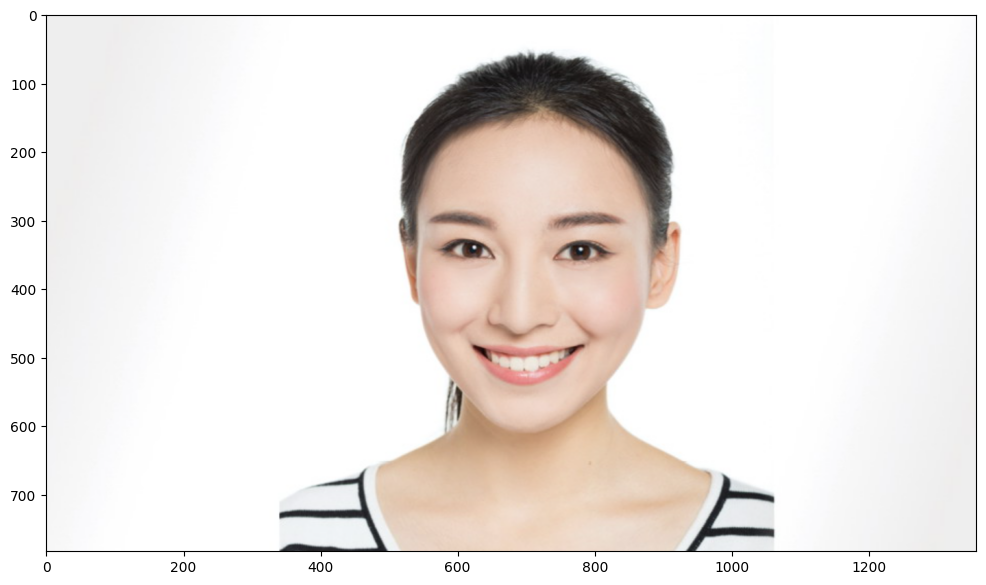

In [3]:
import cv2
import matplotlib.pyplot as plt # 用于绘制图像
img = cv2.imread('test.png')
# cv2.imshow('img',img)
img2 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,12))
plt.imshow(img2)
print(img.shape)
print(type(img2))
plt.show()

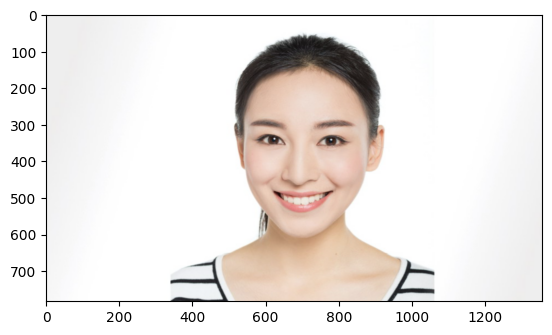

In [4]:
import cv2
import matplotlib.pyplot as plt # 用于绘制图像

img = cv2.imread('test.png')

img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img2)
plt.show()

In [11]:
import cv2
import matplotlib.pyplot as plt # 用于绘制图像

img = cv2.imread('test.png')
cv2.imshow('image', img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imshow('gray', gray)
threash, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
print(threash)
cv2.imshow('binary', binary)
threash,binaru = cv2.threshold(gray, 140, 255,cv2.THRESH_BINARY)
print(cv2.THRESH_BINARY)
cv2.imshow('binaru', binaru)
cv2.waitKey(0)
cv2.destroyAllWindows()

160.0
0


In [21]:
import cv2 
import numpy as np
img = cv2.imread('test.png')


h,w = img.shape[0:2]
print(h,w)
center = (w//2, h//2)
cv2.circle(img, center, 50, (255,0,0), -1)
cv2.imshow('image', img)
M = cv2.getRotationMatrix2D(center, 90, 1.0)
print(M)
w2 = int (w * np.abs(M[0,1]) + h * np.abs(M[0,0]))
h2 = int (h * np.abs(M[0,1]) + w * np.abs(M[0,0]))
print(w2,h2)
M[0,2] += (w2 - w) // 2
M[1,2] += (h2 - h) // 2
rotated = cv2.warpAffine(img, M, (w2, h2))
cv2.imshow('rotated', rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

783 1357
[[ 6.123234e-17  1.000000e+00  2.870000e+02]
 [-1.000000e+00  6.123234e-17  1.069000e+03]]
1357 783


In [22]:
import cv2 
img = cv2.imread('test.png')
cv2.imshow('image', img)
img2 = cv2.resize(img, (1280, 720))
cv2.imshow('image2', img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

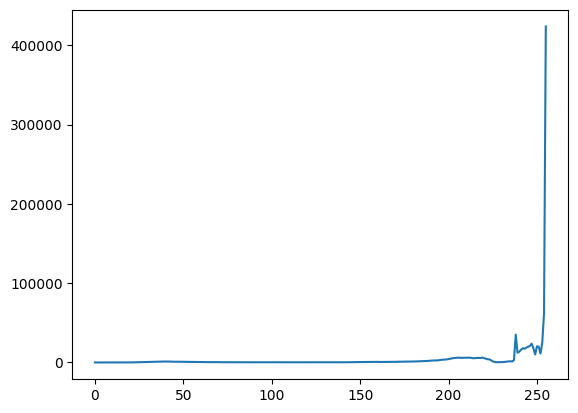

In [26]:
import cv2 as cv
from matplotlib import pyplot as plt
img = cv.imread('test.png')
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow('image', img)
hist = cv.calcHist([img], [0], None, [256], [0, 256])
plt.plot(hist)
plt.show()
cv.waitKey(0)
cv.destroyAllWindows()

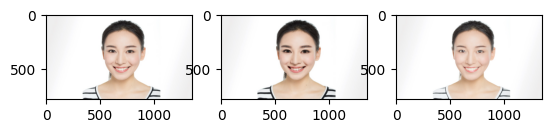

In [32]:
import cv2 as cv
from matplotlib import pyplot as plt
img = cv.imread('test.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
kernel = np.ones((5,5),np.uint8)
erosion = cv.erode(img, kernel)
dilate = cv.dilate(img, kernel)
fig,axes = plt.subplots(1,3)
axes[0].imshow(img,)
axes[1].imshow(erosion)
axes[2].imshow(dilate)
plt.show()

In [38]:
import cv2 as cv
import numpy as np

img = cv.imread('e:\me.jpg')
cv.imshow('img', img)
img2 = cv.flip(img, 1)
cv.imshow('img2', img2)
cv.imwrite('e:\me2.jpg', img2)
img3 = cv.flip(img, 0)
cv.imshow('img3', img3)
cv.waitKey(0)
cv.destroyAllWindows()

In [51]:
import cv2
import numpy as np

img = cv2.imread('test.png', 0)

# 1. 二值化处理（可选，但通常投影用于二值图效果更好）
# 这一步将图像变为纯黑(0)和纯白(255)，方便统计
_, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 2. 计算水平投影
# 沿列方向求和，得到每一行的白色像素总数
hist = np.sum(img, axis=1)

# 3. 将一维数组转换为二维图像以便显示
# 方法 A: 简单转置，变成 (height, 1) 的图像
# hist_img = hist.reshape(-1, 1) 

# 方法 B: 归一化并放大显示（推荐，更直观）
# 将数据归一化到 0-255 范围，方便显示
hist_normalized = hist.astype(np.float32) 
# 防止除以0
if np.max(hist_normalized) > 0:
    hist_normalized = (hist_normalized / np.max(hist_normalized)) * 255
hist_normalized = hist_normalized.astype(np.uint8)

# 将其拉伸为一个宽=图像宽，高=图像高的图像
# 使用 np.repeat 在水平方向重复每一行
hist_img = np.repeat(hist_normalized.reshape(-1, 1), img.shape[1], axis=1)

# 4. 显示结果
cv2.imshow('Original', img)
cv2.imshow('Horizontal Projection', hist_img)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [60]:
import cv2
import numpy as np

img = cv2.imread('test.png', cv.IMREAD_COLOR)
print(img.shape)
cv.imshow('image', img)
hist = np.sum(img, axis=1)
print(hist.shape)
# cv2.imshow('hist', hist)
cv.waitKey(0)
cv.destroyAllWindows()

(783, 1357, 3)
(783, 3)


In [71]:
import cv2 as cv
import numpy as np

img = cv.imread('E:\\1.png')
cv.imshow('img', img)
template = cv.imread('e:\\2.png')
cv.imshow('template', template)
result = cv.matchTemplate(img, template, cv.TM_CCOEFF_NORMED)
cv.imshow('result', result)
print(result.max())
min_val,max_val,min_loc,max_loc = cv.minMaxLoc(result)
top_left = max_loc
bottom_right = (top_left[0] + template.shape[1], top_left[1] + template.shape[0])
cv.rectangle(img, top_left, bottom_right, (0,0,255), 2)
cv.imshow('img2', img)
cv.waitKey(0)
cv.destroyAllWindows()

1.0
